In [461]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

from functions.read_g4bl_data import readTraceData, readDetData
from functions.set_plot_settings import setPlotSettings

setPlotSettings(font=True)

In [462]:
data = readTraceData('AllTracks.txt')

In [463]:
# remove last period (for fringe-field mitigation)
# 2 periods HFOFO + 1 at start + 1 at end
period_len = 4200
data = data[data['z'] < 500+period_len*2]

In [464]:
data = data.sort_values('z')

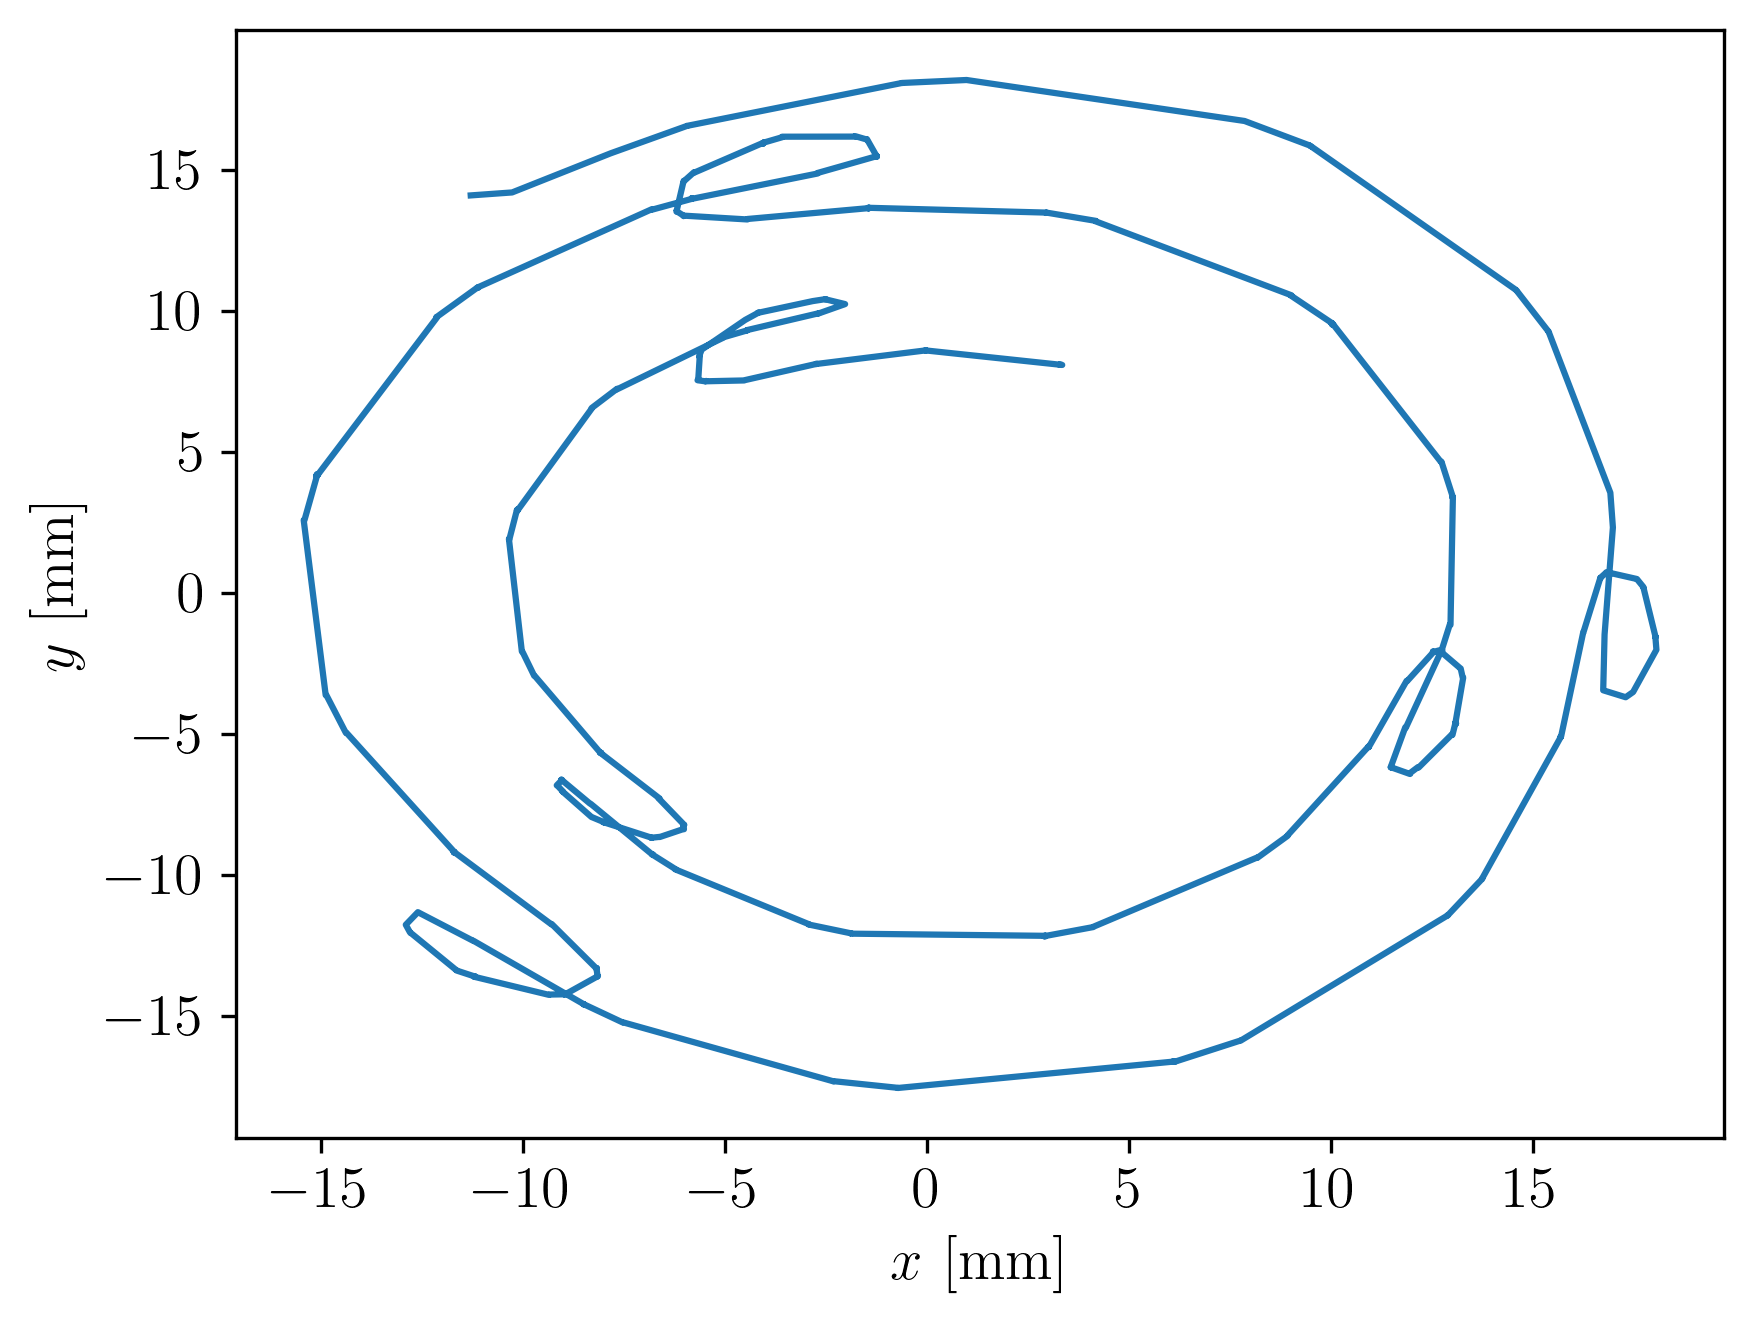

In [465]:
plt.plot(data['x'], data['y'])
plt.xlabel('$x$ [mm]')
plt.ylabel('$y$ [mm]');

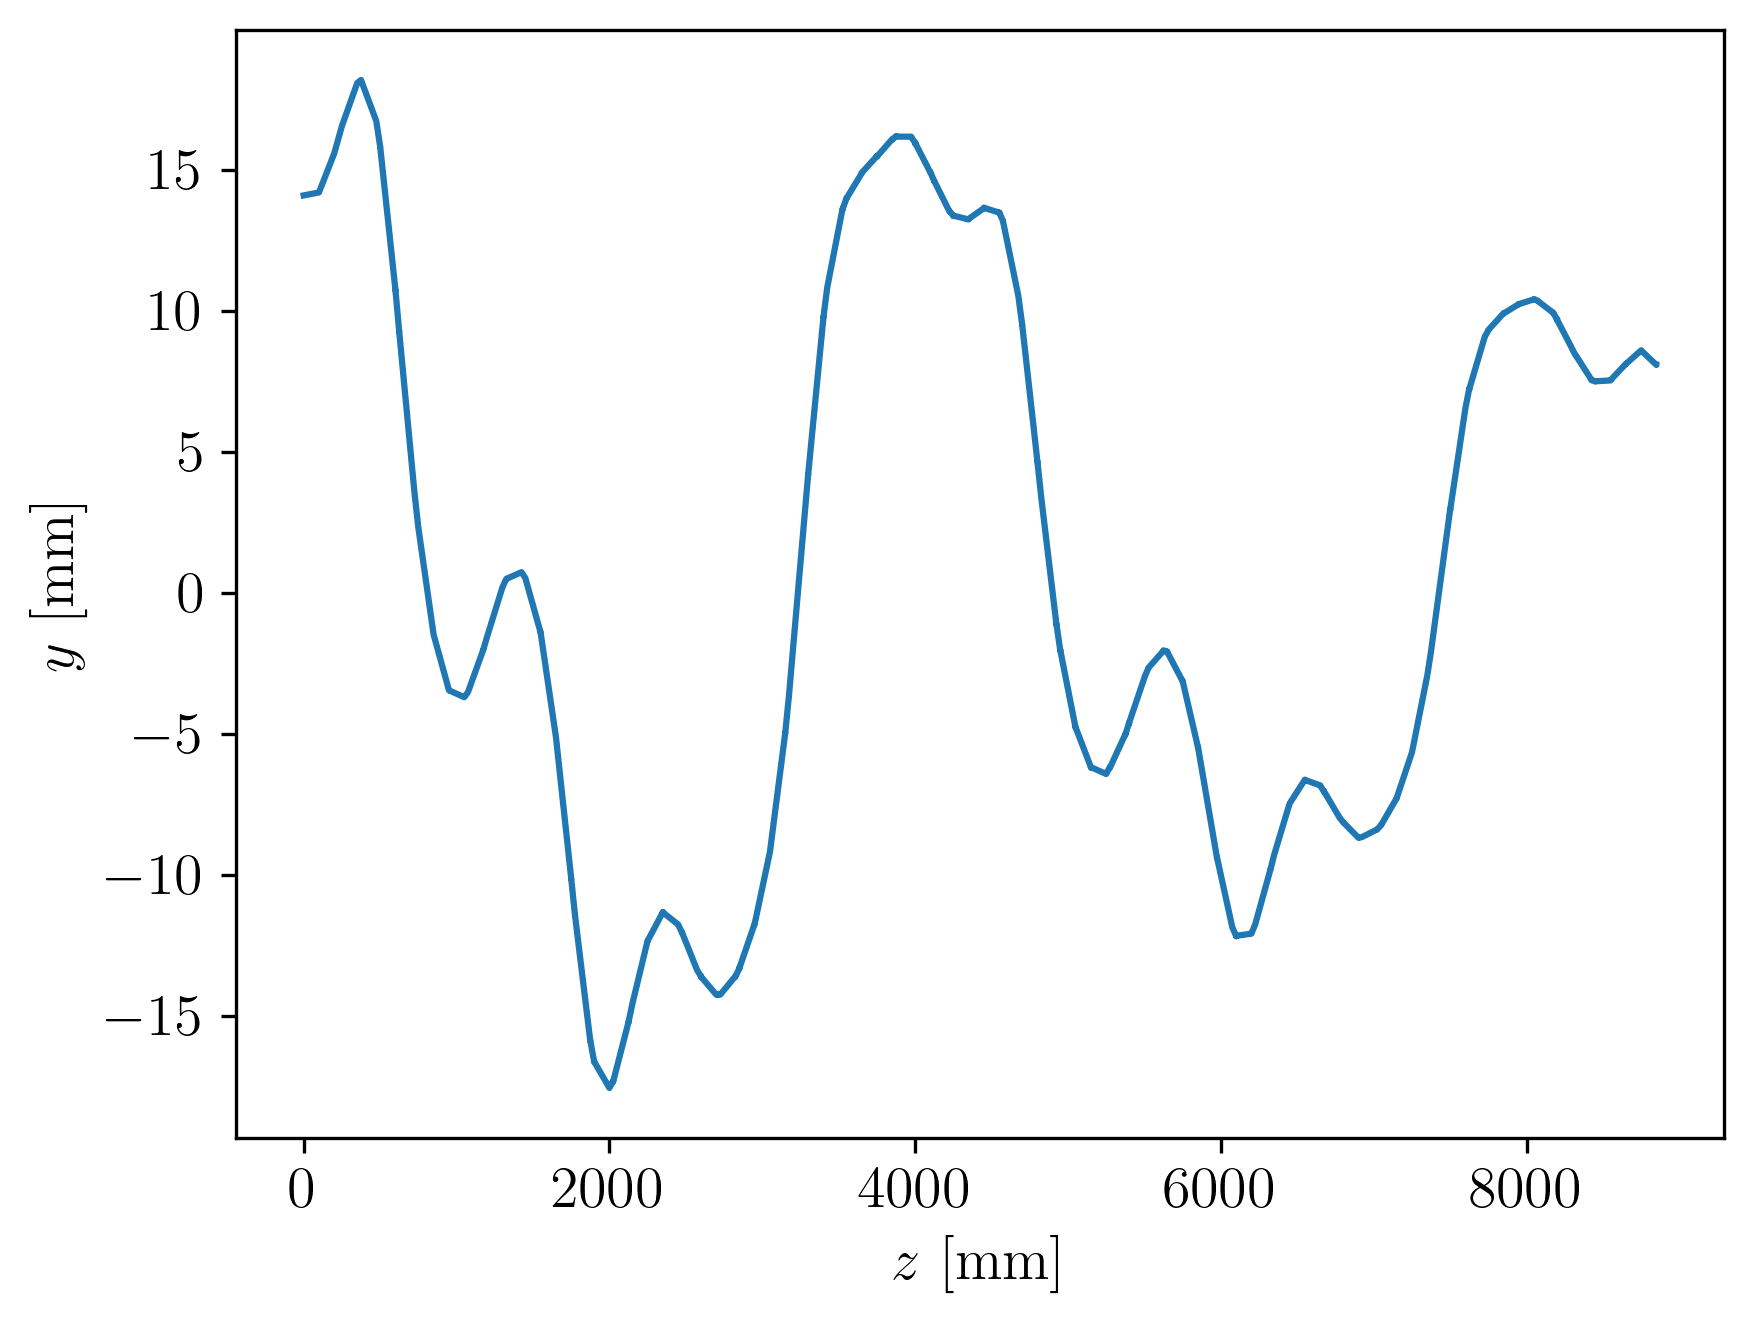

In [466]:
plt.plot(data['z'], data['y'])
plt.xlabel('$z$ [mm]')
plt.ylabel('$y$ [mm]');

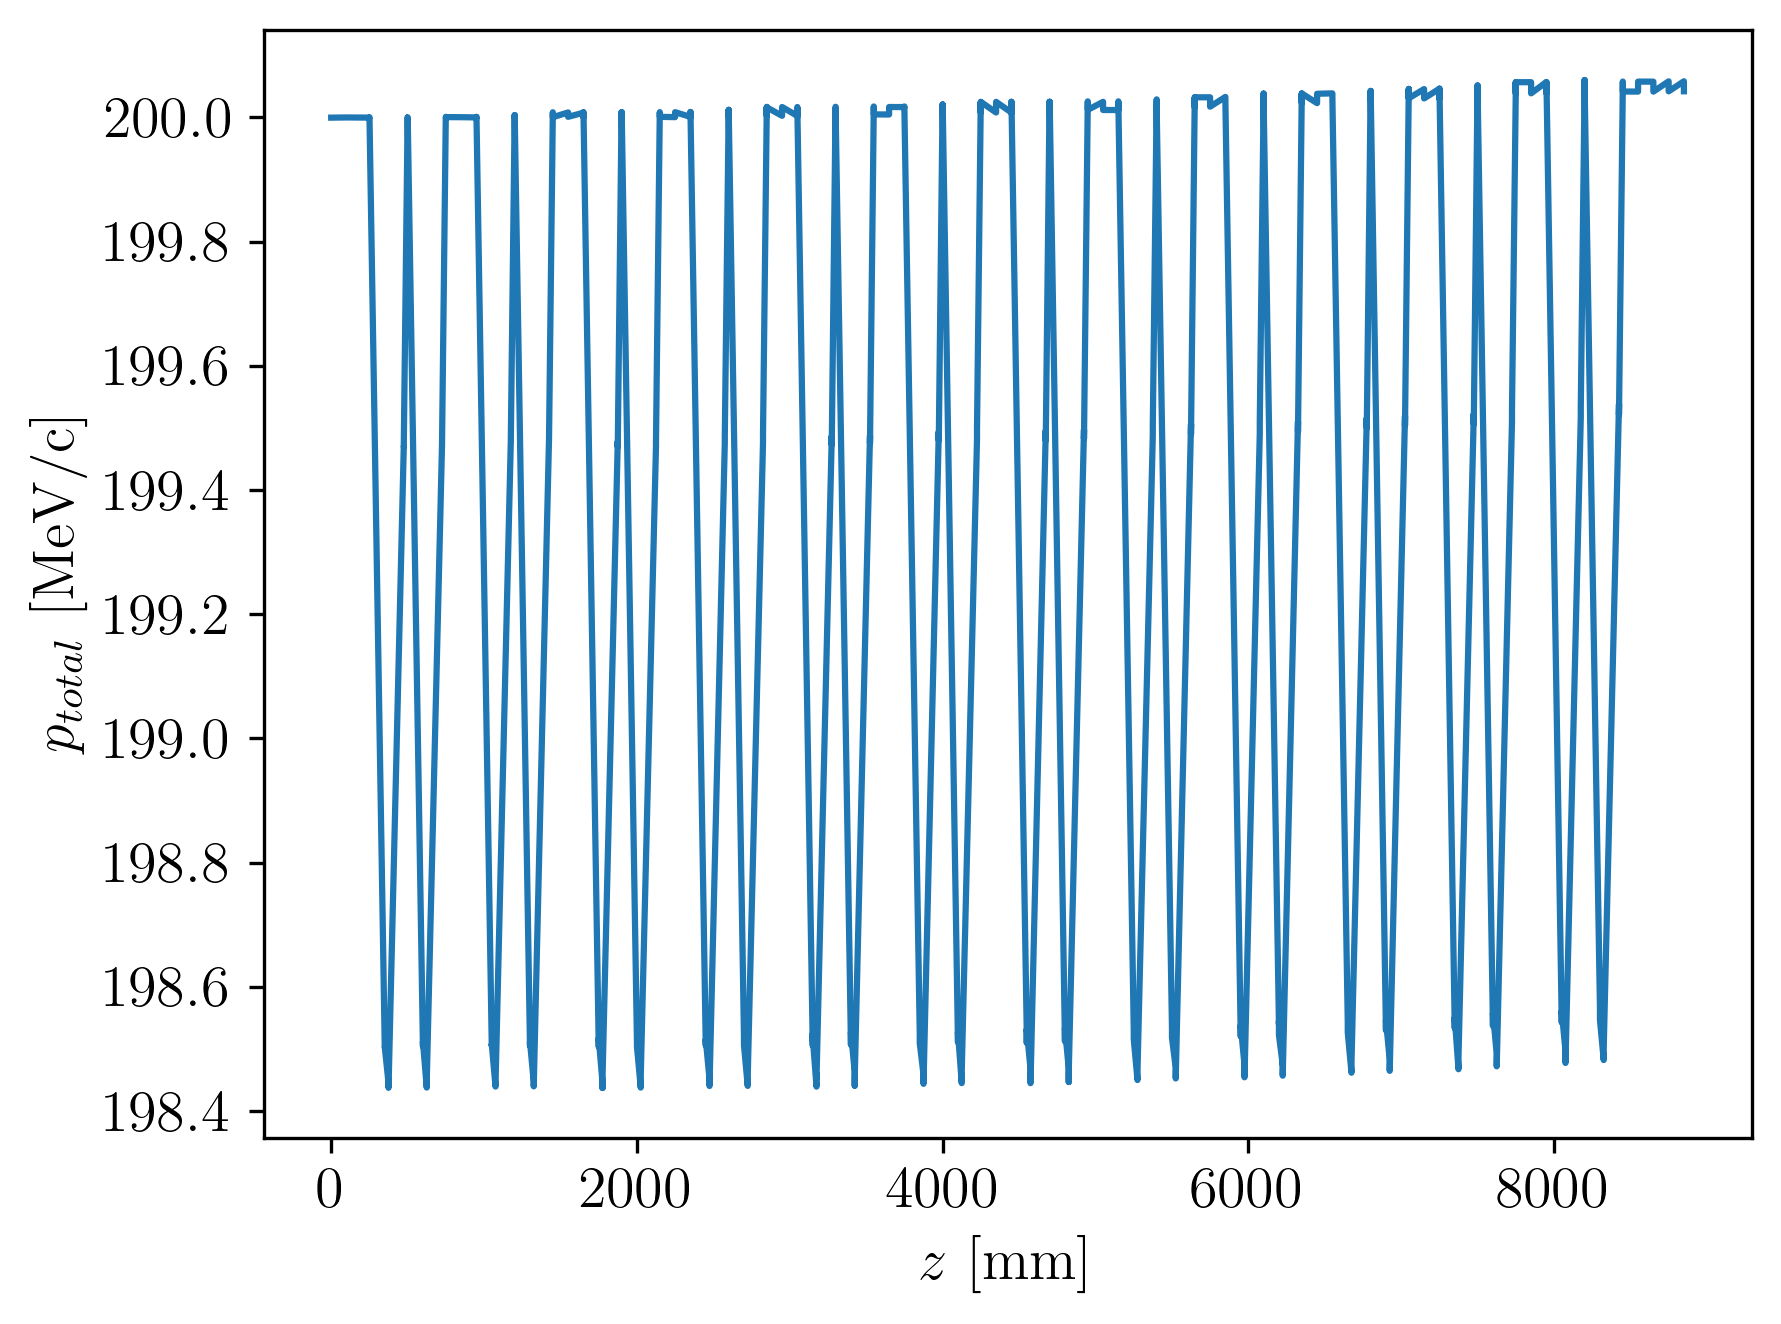

In [467]:
plt.plot(data['z'], data['ptotal'])
plt.xlabel('$z$ [mm]')
plt.ylabel('$p_{total}$ [MeV/c]');

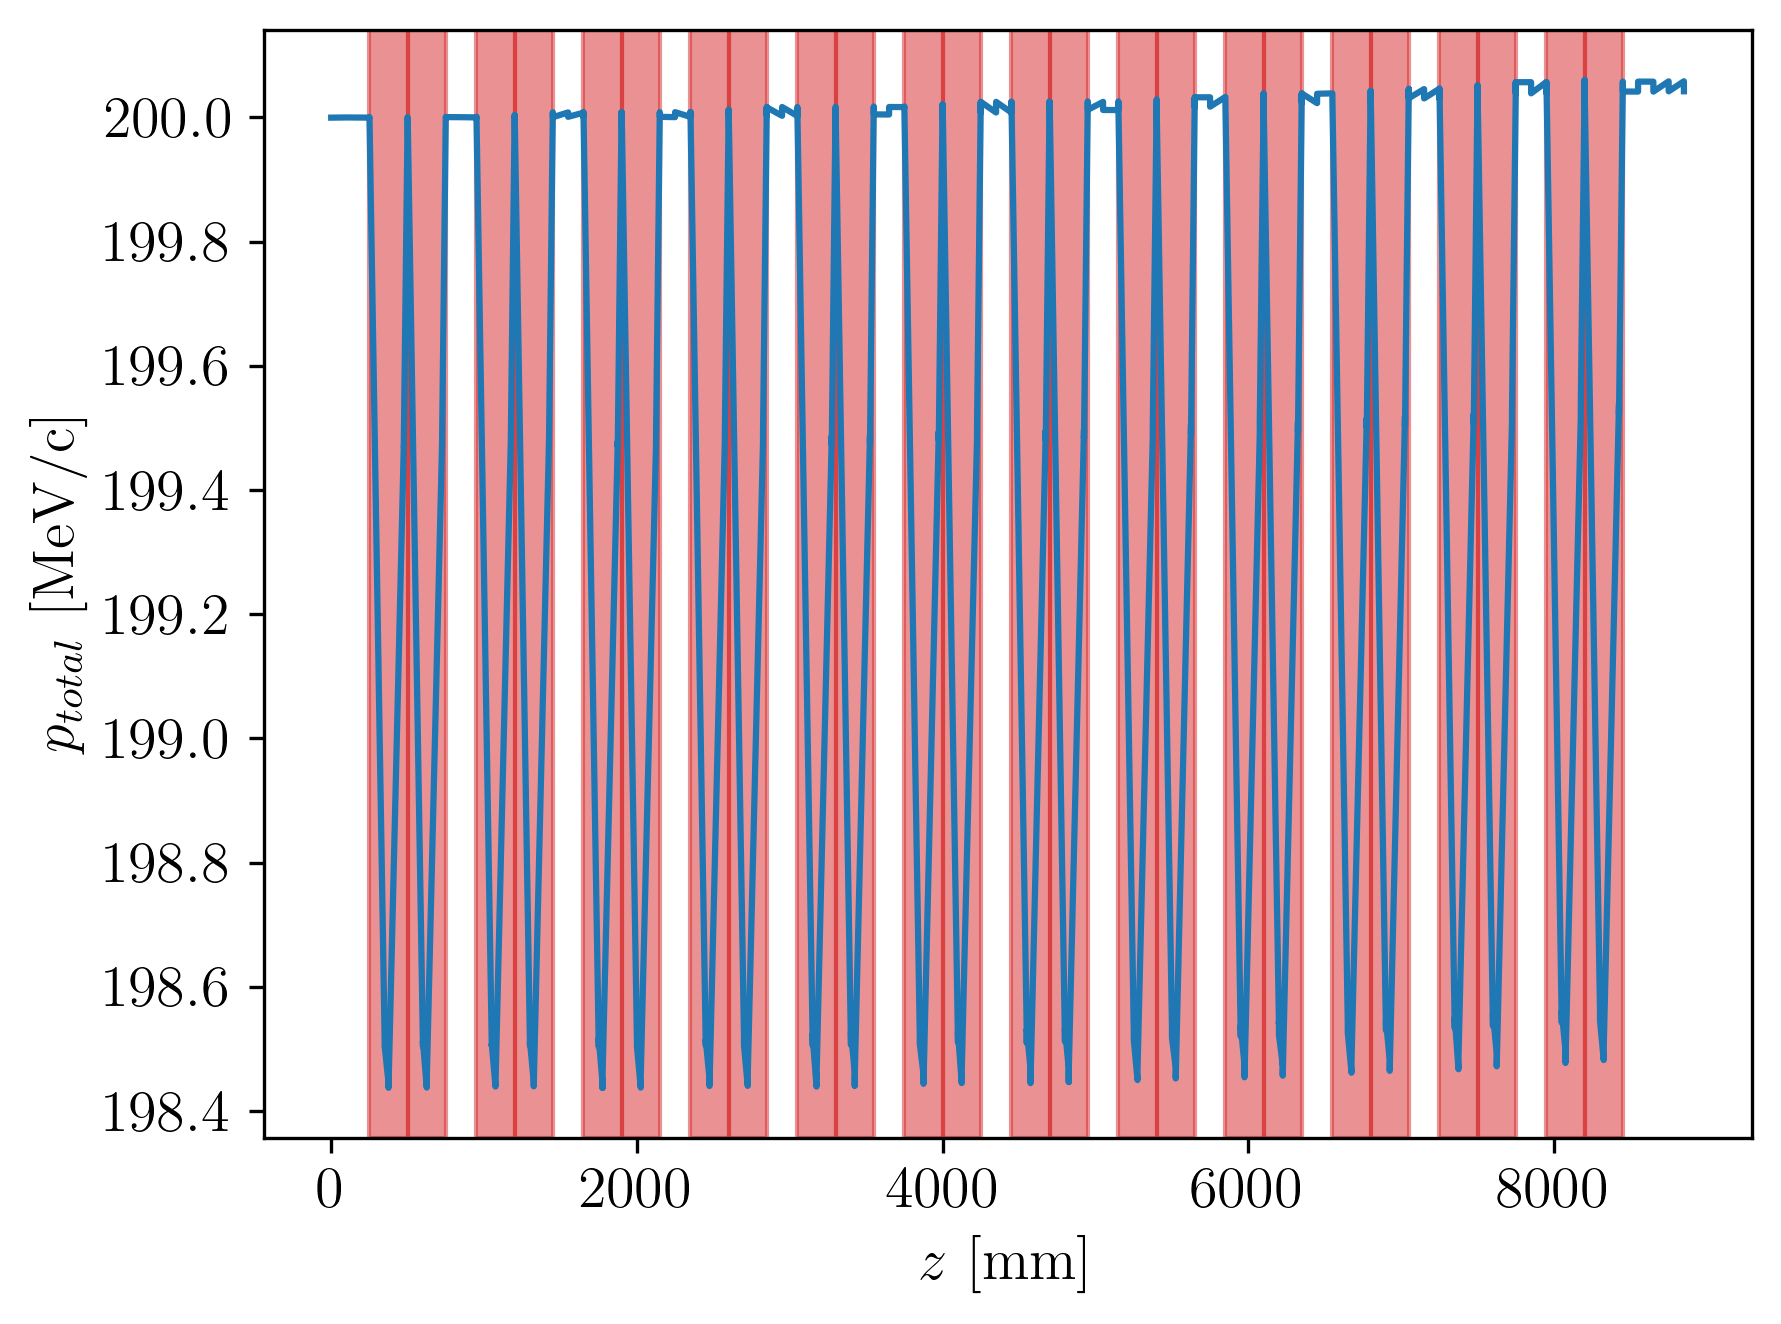

In [468]:
plt.plot(data['z'], data['ptotal'])
plt.xlabel('$z$ [mm]')
plt.ylabel('$p_{total}$ [MeV/c]')
# plt.xlim(500,4700)
rf_len = 250
space = period_len/6
for i in range(12):
    z1 = 500-rf_len/2+space*i
    z2 = 500+rf_len/2+space*i
    plt.axvspan(xmin=z1-rf_len/2,xmax=z1+rf_len/2,color='tab:red',alpha=0.5,zorder=-0.5)
    plt.axvspan(xmin=z2-rf_len/2,xmax=z2+rf_len/2,color='tab:red',alpha=0.5,zorder=-0.5)

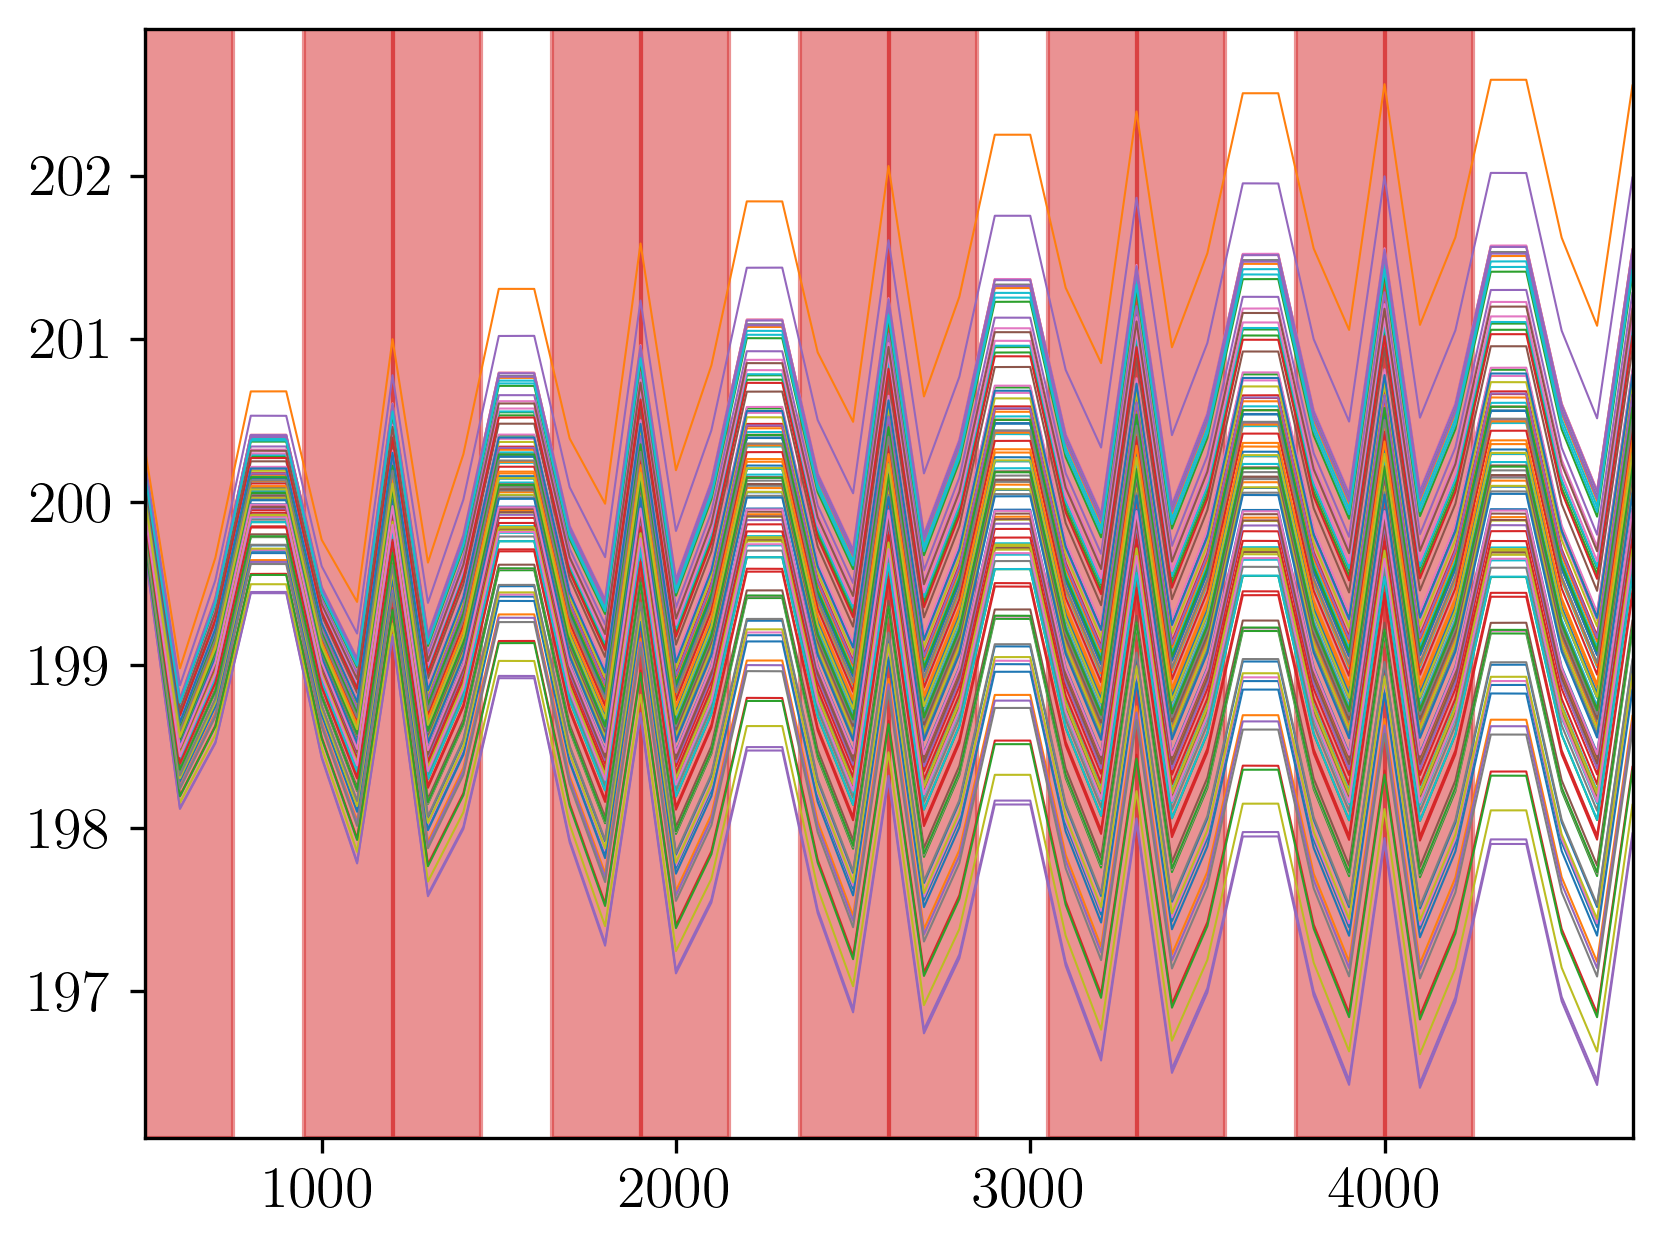

In [469]:
data_beam = readDetData('zntuple.txt')
for ID in np.unique(data_beam['EventID']):
    plt.plot(data_beam[data_beam['EventID']==ID]['z'], data_beam[data_beam['EventID']==ID]['ptotal'],lw=0.5)
plt.xlim(500,4700)
for i in range(6):
    z1 = 500-rf_len/2+space*i
    z2 = 500+rf_len/2+space*i
    plt.axvspan(xmin=z1-rf_len/2,xmax=z1+rf_len/2,color='tab:red',alpha=0.5,zorder=-0.5)
    plt.axvspan(xmin=z2-rf_len/2,xmax=z2+rf_len/2,color='tab:red',alpha=0.5,zorder=-0.5)

In [470]:
# figuring out how to implement mod in G4bl
# (because it does not have mod natively)
def my_mod(val1, val2):
    # val1 % val2
    return val1 - np.floor(val1/val2)*val2

# test:
print(3141 % 42)
print(my_mod(3141,42))

33
33.0


In [471]:
rf_period = (1/325)*10**3
print(rf_period)

3.076923076923077
